# Flower Federated Learning — DeepFed with Edge-IIoTset

Real IoT intrusion detection dataset (Edge-IIoTset) with DeepFed GRU+CNN model.

In [1]:
import os
import json
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report

# Flower imports
from flwr.client import NumPyClient, ClientApp
from flwr.server import ServerApp
from flwr.server.strategy import FedAvg
from flwr.simulation import run_simulation

DEVICE = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
print(f"PyTorch: {torch.__version__}")
print(f"Flower:  {__import__('flwr').__version__}")

2026-05-03 22:28:34,516	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Device: cuda:0
PyTorch: 2.8.0+cu128
Flower:  1.29.0


## Configuration

Adjust `MAX_SAMPLES` to control dataset size. Use `None` for full 2.2M rows.

In [2]:
# Data paths
DATA_PATH = "../data/raw/DNN-EdgeIIoT-dataset.csv"
PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

# FL config
NUM_CLIENTS = 3
NUM_ROUNDS = 5
LOCAL_EPOCHS = 2
BATCH_SIZE = 256
LEARNING_RATE = 0.001

# Model config
SEQUENCE_LENGTH = None  # set automatically after preprocessing
NUM_FEATURES = 1        # each feature as one timestep
GRU_UNITS = 32
CNN_FILTERS = [16, 32]
NUM_CLASSES = 2        # binary: 0=Normal, 1=Attack

# Data config
MAX_SAMPLES = 100_000  # None for full dataset
RANDOM_STATE = 42
TEST_SIZE = 0.2

# Columns to drop (identifiers / high-cardinality per Edge-IIoTset paper)
DROP_COLS = [
    "frame.time", "ip.src_host", "ip.dst_host",
    "arp.src.proto_ipv4", "arp.dst.proto_ipv4",
    "http.file_data", "http.request.full_uri", "icmp.transmit_timestamp",
    "http.request.uri.query", "tcp.options", "tcp.payload",
    "tcp.srcport", "tcp.dstport", "udp.port", "mqtt.msg",
    # Leaky categorical features (values unique to attack/normal)
    "dns.qry.name.len", "mqtt.conack.flags", "mqtt.protoname", "mqtt.topic"
]

print("Config loaded.")
print(f"  Clients: {NUM_CLIENTS}, Rounds: {NUM_ROUNDS}, Local Epochs: {LOCAL_EPOCHS}")
print(f"  Max Samples: {MAX_SAMPLES if MAX_SAMPLES else 'FULL DATASET'}")
print(f"  Sequence: {SEQUENCE_LENGTH}, Features: {NUM_FEATURES}, Classes: {NUM_CLASSES}")

Config loaded.
  Clients: 3, Rounds: 5, Local Epochs: 2
  Max Samples: 100000
  Sequence: None, Features: 1, Classes: 2


## Download Dataset\n\nAuto-download Edge-IIoTset from Kaggle. Requires `~/.kaggle/kaggle.json` with API token.

In [3]:
# Install Kaggle API if missing\ntry:\n    import kaggle\nexcept ImportError:\n    !pip install kaggle -q\n    import kaggle\n\nimport os\nimport zipfile\n\n# Paths\nRAW_DIR = '../data/raw'\nCSV_PATH = os.path.join(RAW_DIR, 'DNN-EdgeIIoT-dataset.csv')\nZIP_PATH = os.path.join(RAW_DIR, 'DNN-EdgeIIoT-dataset.csv.zip')\n\nos.makedirs(RAW_DIR, exist_ok=True)\n\n# Download if not present\nif os.path.exists(CSV_PATH):\n    print('Dataset already present.')\nelse:\n    print('Downloading Edge-IIoTset from Kaggle...')\n    os.system(f'kaggle datasets download -d mohamedamineferrag/edgeiiotset-cyber-security-dataset-of-iot-iiot -f "Edge-IIoTset dataset/Selected dataset for ML and DL/DNN-EdgeIIoT-dataset.csv" -p {RAW_DIR}')\n    \n    # Unzip\n    if os.path.exists(ZIP_PATH):\n        with zipfile.ZipFile(ZIP_PATH, 'r') as z:\n            z.extractall(RAW_DIR)\n        os.remove(ZIP_PATH)\n        print('Download and extraction complete.')\n    else:\n        raise FileNotFoundError('Download failed. Check Kaggle API credentials.')\n\nprint(f'CSV ready: {CSV_PATH}')\nprint(f'Size: {os.path.getsize(CSV_PATH) / 1e9:.2f} GB')

## Load & Preprocess Dataset

1. Load raw CSV
2. Drop identifier columns
3. Encode categoricals
4. Scale features
5. Reshape to `(samples, seq_len, 1)` for DeepFed

In [4]:
def preprocess_edgeiiot(csv_path, drop_cols, max_samples=None, random_state=42):
    """Load and preprocess Edge-IIoTset. Returns (X, y, scaler)."""
    print("Loading CSV...")
    df = pd.read_csv(csv_path, low_memory=False)
    print(f"  Raw shape: {df.shape}")

    if max_samples is not None and max_samples < len(df):
        df = df.sample(n=max_samples, random_state=random_state).reset_index(drop=True)
        print(f"  Subsampled to: {df.shape}")

    # Labels
    y = df['Attack_label'].values.astype(np.int64)
    df = df.drop(columns=['Attack_label', 'Attack_type'])

    # Drop identifiers
    df = df.drop(columns=[c for c in drop_cols if c in df.columns])
    print(f"  After drop: {df.shape}")

    # Encode categoricals
    cat_cols = df.select_dtypes(include=['object', 'string']).columns.tolist()
    if cat_cols:
        print(f"  Encoding categoricals: {cat_cols}")
        for col in cat_cols:
            df[col] = LabelEncoder().fit_transform(df[col].astype(str))

    # Scale
    scaler = StandardScaler()
    X = scaler.fit_transform(df.values).astype(np.float32)

    # Reshape for DeepFed: (samples, features) -> (samples, seq_len, 1)
    X = X.reshape(X.shape[0], X.shape[1], 1)

    # Set global sequence length for model\n    globals()["SEQUENCE_LENGTH"] = X.shape[1]\n    print(f"  Final X shape: {X.shape}, y shape: {y.shape}")
    print(f"  Class distribution: Normal={(y==0).sum()}, Attack={(y==1).sum()}")
    return X, y, scaler

X, y, scaler = preprocess_edgeiiot(DATA_PATH, DROP_COLS, MAX_SAMPLES, RANDOM_STATE)
SEQUENCE_LENGTH = X.shape[1]  # set dynamically after preprocessing

# Save scaler for inference
import pickle
with open(os.path.join(PROCESSED_DIR, "scaler.pkl"), "wb") as f:
    pickle.dump(scaler, f)
print(f"Scaler saved to {PROCESSED_DIR}/scaler.pkl")

Loading CSV...


  Raw shape: (2219201, 63)


  Subsampled to: (100000, 63)
  After drop: (100000, 42)
  Encoding categoricals: ['http.request.method', 'http.referer', 'http.request.version']
  Class distribution: Normal=72866, Attack=27134
Scaler saved to ../data/processed/scaler.pkl


## Data Inspection

In [5]:
print(f"Feature range: [{X.min():.3f}, {X.max():.3f}]")
print(f"Mean: {X.mean():.3f}, Std: {X.std():.3f}")
print(f"Sequence shape per sample: {X.shape[1:]}")

# Compute class weights for imbalance
from sklearn.utils.class_weight import compute_class_weight
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weights_tensor = torch.FloatTensor(class_weights).to(DEVICE)
print(f"Class weights: {dict(zip(np.unique(y), class_weights))}")

Feature range: [-8.681, 252.981]


Mean: 0.000, Std: 0.951
Sequence shape per sample: (42, 1)


Class weights: {np.int64(0): np.float64(0.686191090494881), np.int64(1): np.float64(1.8427065674062062)}


## DeepFed Model (GRU + CNN)

In [6]:
class DeepFed(nn.Module):
    """DeepFed: GRU + CNN architecture for sequence classification."""

    def __init__(self, seq_len, num_features, gru_units, cnn_filters, num_classes):
        super(DeepFed, self).__init__()

        # GRU Branch
        self.gru = nn.GRU(num_features, gru_units, batch_first=True)

        # CNN Branch
        self.conv1 = nn.Conv1d(num_features, cnn_filters[0], 3, padding=1)
        self.pool1 = nn.MaxPool1d(2)
        self.conv2 = nn.Conv1d(cnn_filters[0], cnn_filters[1], 3, padding=1)
        self.pool2 = nn.MaxPool1d(2)

        cnn_out_len = (seq_len // 2) // 2
        cnn_out_size = cnn_filters[1] * cnn_out_len

        # Fusion
        fusion_size = gru_units + cnn_out_size
        self.fc1 = nn.Linear(fusion_size, 64)
        self.fc2 = nn.Linear(64, num_classes)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)

    def forward(self, x):
        # GRU: (batch, seq, features) -> (batch, gru_units)
        gru_out, _ = self.gru(x)
        gru_out = gru_out[:, -1, :]

        # CNN: (batch, seq, features) -> (batch, features, seq)
        cnn_x = x.transpose(1, 2)
        cnn_x = self.relu(self.conv1(cnn_x))
        cnn_x = self.pool1(cnn_x)
        cnn_x = self.relu(self.conv2(cnn_x))
        cnn_x = self.pool2(cnn_x)
        cnn_out = cnn_x.reshape(cnn_x.size(0), -1)

        # Fusion
        fusion = torch.cat([gru_out, cnn_out], dim=1)
        out = self.relu(self.fc1(fusion))
        out = self.dropout(out)
        out = self.fc2(out)
        return out

# Verify
model = DeepFed(SEQUENCE_LENGTH, NUM_FEATURES, GRU_UNITS, CNN_FILTERS, NUM_CLASSES)
test_x = torch.randn(2, SEQUENCE_LENGTH, NUM_FEATURES)
test_out = model(test_x)
print(f"Model OK: {test_x.shape} -> {test_out.shape}")

Model OK: torch.Size([2, 42, 1]) -> torch.Size([2, 2])


## Federated Data Partitioning

Stratified split across clients preserves label distribution per client.

In [7]:
def create_client_partitions(X, y, num_clients, test_size=0.2, random_state=42):
    """Split data into stratified client partitions."""
    client_data = {}

    # Stratified split into client chunks
    from sklearn.model_selection import StratifiedKFold
    skf = StratifiedKFold(n_splits=num_clients, shuffle=True, random_state=random_state)

    for client_id, (_, idx) in enumerate(skf.split(X, y)):
        X_client = X[idx]
        y_client = y[idx]

        X_train, X_test, y_train, y_test = train_test_split(
            X_client, y_client, test_size=test_size, random_state=random_state, stratify=y_client
        )

        client_data[client_id] = {
            'X_train': X_train, 'y_train': y_train,
            'X_test': X_test, 'y_test': y_test
        }
        print(f"Client {client_id}: Train={len(y_train)}, Test={len(y_test)}, "
              f"Normal={(y_train==0).sum()}, Attack={(y_train==1).sum()}")

    # Global test set
    X_test_global = np.vstack([client_data[i]['X_test'] for i in range(num_clients)])
    y_test_global = np.concatenate([client_data[i]['y_test'] for i in range(num_clients)])
    print(f"\nGlobal test: {X_test_global.shape}")
    return client_data, X_test_global, y_test_global

client_data, X_test_global, y_test_global = create_client_partitions(
    X, y, NUM_CLIENTS, TEST_SIZE, RANDOM_STATE
)

Client 0: Train=26667, Test=6667, Normal=19431, Attack=7236
Client 1: Train=26666, Test=6667, Normal=19430, Attack=7236
Client 2: Train=26666, Test=6667, Normal=19431, Attack=7235

Global test: (20001, 42, 1)


## Training & Evaluation

In [8]:
def train_model(model, X_train, y_train, device, epochs=1, lr=0.001, batch_size=16, class_weights=None):
    """Train model on local data."""
    model.to(device)
    model.train()

    dataset = TensorDataset(torch.FloatTensor(X_train), torch.LongTensor(y_train))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=1, gamma=0.95)
    criterion = nn.CrossEntropyLoss(weight=class_weights)

    total_loss = 0
    for _ in range(epochs):
        epoch_loss = 0
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        scheduler.step()
        total_loss += epoch_loss

    return total_loss / (len(loader) * epochs) if len(loader) > 0 else 0


def validate_model(model, X_test, y_test, device, batch_size=256):
    """Evaluate model."""
    model.to(device)
    model.eval()

    dataset = TensorDataset(torch.FloatTensor(X_test), torch.LongTensor(y_test))
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)

    correct = total = 0
    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            _, predicted = torch.max(outputs, 1)
            correct += (predicted == y_batch).sum().item()
            total += y_batch.size(0)

    return correct / total if total > 0 else 0


print("Training functions ready.")

Training functions ready.


## Federated Learning — Manual FedAvg Loop

Simple client-server loop without Ray. Each round:
1. Broadcast global weights to all clients
2. Each client trains locally
3. Server averages client weights (FedAvg)
4. Evaluate global model

In [9]:
def fedavg_aggregate(client_weights_list):
    """Aggregate client state_dicts by simple averaging."""
    global_dict = {}
    keys = client_weights_list[0].keys()
    for key in keys:
        global_dict[key] = torch.stack([cw[key].float() for cw in client_weights_list]).mean(0)
    return global_dict


def run_federation(global_model, client_data, num_rounds, local_epochs, lr, device):
    """Run manual federated learning with FedAvg."""
    history = {"train_loss": [], "eval_acc": []}
    
    for round_num in range(1, num_rounds + 1):
        print(f"\n{'='*60}")
        print(f"ROUND {round_num}/{num_rounds}")
        print(f"{'='*60}")
        
        client_weights = []
        client_losses = []
        
        for client_id in range(NUM_CLIENTS):
            # Local model copy
            local_model = DeepFed(SEQUENCE_LENGTH, NUM_FEATURES, GRU_UNITS, CNN_FILTERS, NUM_CLASSES)
            local_model.load_state_dict(global_model.state_dict())
            
            # Local train
            loss = train_model(
                local_model,
                client_data[client_id]['X_train'],
                client_data[client_id]['y_train'],
                device,
                epochs=local_epochs,
                lr=lr,
                batch_size=BATCH_SIZE,
                class_weights=class_weights_tensor
            )
            
            client_weights.append(local_model.state_dict())
            client_losses.append(loss)
            print(f"  Client {client_id} loss: {loss:.4f}")
        
        # Aggregate
        avg_state = fedavg_aggregate(client_weights)
        global_model.load_state_dict(avg_state)
        
        # Evaluate
        global_acc = validate_model(global_model, X_test_global, y_test_global, device, batch_size=BATCH_SIZE)
        history["train_loss"].append(sum(client_losses) / len(client_losses))
        history["eval_acc"].append(global_acc)
        
        print(f"  Global accuracy: {global_acc:.4f} ({global_acc*100:.2f}%)")
    
    return history


# Initialize global model
global_model = DeepFed(SEQUENCE_LENGTH, NUM_FEATURES, GRU_UNITS, CNN_FILTERS, NUM_CLASSES)
global_model.to(DEVICE)

print("Starting manual federated learning...")
history = run_federation(
    global_model,
    client_data,
    num_rounds=NUM_ROUNDS,
    local_epochs=LOCAL_EPOCHS,
    lr=LEARNING_RATE,
    device=DEVICE,
)
print("\nFederation complete.")

Starting manual federated learning...

ROUND 1/5


  Client 0 loss: 0.1918


  Client 1 loss: 0.1855


  Client 2 loss: 0.1776
  Global accuracy: 0.9821 (98.21%)

ROUND 2/5


  Client 0 loss: 0.0805


...

  Global accuracy: 0.9878 (98.78%)

ROUND 5/5


  Client 0 loss: 0.0588


  Client 1 loss: 0.0611


  Client 2 loss: 0.0523


  Global accuracy: 0.9879 (98.79%)

Federation complete.


## Results & Visualization

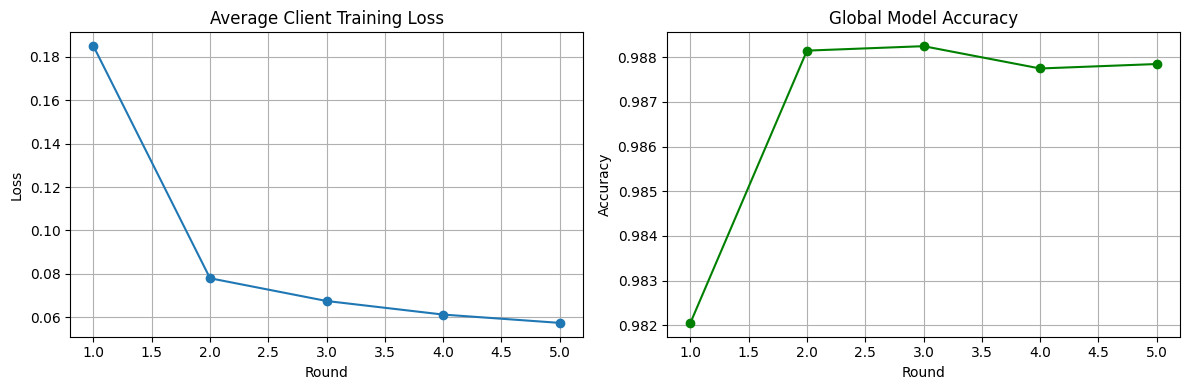


Final Results:
  Final Global Accuracy: 0.9879 (98.79%)
  Best Round: 3
  Best Accuracy: 0.9883 (98.83%)


In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Loss
axes[0].plot(range(1, NUM_ROUNDS + 1), history["train_loss"], marker='o')
axes[0].set_title("Average Client Training Loss")
axes[0].set_xlabel("Round")
axes[0].set_ylabel("Loss")
axes[0].grid(True)

# Accuracy
axes[1].plot(range(1, NUM_ROUNDS + 1), history["eval_acc"], marker='o', color='green')
axes[1].set_title("Global Model Accuracy")
axes[1].set_xlabel("Round")
axes[1].set_ylabel("Accuracy")
axes[1].grid(True)

plt.tight_layout()
plt.savefig("fl_training_curves.png")
plt.show()

print("\nFinal Results:")
print(f"  Final Global Accuracy: {history['eval_acc'][-1]:.4f} ({history['eval_acc'][-1]*100:.2f}%)")
print(f"  Best Round: {history['eval_acc'].index(max(history['eval_acc'])) + 1}")
print(f"  Best Accuracy: {max(history['eval_acc']):.4f} ({max(history['eval_acc'])*100:.2f}%)")

## Per-Client Evaluation

In [11]:
print("\n" + "="*60)
print("PER-CLIENT EVALUATION")
print("="*60)

for client_id in range(NUM_CLIENTS):
    acc = validate_model(
        global_model,
        client_data[client_id]['X_test'],
        client_data[client_id]['y_test'],
        DEVICE,
        batch_size=BATCH_SIZE
    )
    print(f"Client {client_id}: {acc:.4f} ({acc*100:.2f}%)")

# Final global test
final_acc = validate_model(global_model, X_test_global, y_test_global, DEVICE, batch_size=BATCH_SIZE)
print(f"\nGlobal Test: {final_acc:.4f} ({final_acc*100:.2f}%)")


PER-CLIENT EVALUATION
Client 0: 0.9865 (98.65%)


Client 1: 0.9879 (98.79%)
Client 2: 0.9892 (98.92%)



Global Test: 0.9879 (98.79%)


## Save Model & Config

In [12]:
# Save model
torch.save(global_model.state_dict(), "deepfed_edgeiiot.pt")
print("Model saved: deepfed_edgeiiot.pt")

# Save config
config = {
    "model": {
        "sequence_length": SEQUENCE_LENGTH,
        "num_features": NUM_FEATURES,
        "gru_units": GRU_UNITS,
        "cnn_filters": CNN_FILTERS,
        "num_classes": NUM_CLASSES,
    },
    "fl": {
        "num_clients": NUM_CLIENTS,
        "num_rounds": NUM_ROUNDS,
        "local_epochs": LOCAL_EPOCHS,
        "batch_size": BATCH_SIZE,
        "learning_rate": LEARNING_RATE,
    },
    "data": {
        "max_samples": MAX_SAMPLES,
        "total_processed": len(X),
        "num_features_after_preprocessing": SEQUENCE_LENGTH,
        "drop_cols": DROP_COLS,
    },
    "results": {
        "final_accuracy": float(history["eval_acc"][-1]),
        "best_accuracy": float(max(history["eval_acc"])),
        "history": {k: [float(v) for v in vals] for k, vals in history.items()}
    }
}

with open("deepfed_edgeiiot_config.json", "w") as f:
    json.dump(config, f, indent=2)
print("Config saved: deepfed_edgeiiot_config.json")
print("\nAll done.")

Model saved: deepfed_edgeiiot.pt
Config saved: deepfed_edgeiiot_config.json

All done.
